# Story Writing Benchmark - 4. Per-Rubric Alignment Analysis

## Setup

In [9]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 5

ALL_CATEGORIES = [
    "Grammar, Spelling, and Punctuation Quality",
    "Clarity and Understandability",
    "Logical Connection Between Events and Ideas",
    "Scene Construction and Purpose",
    "Internal Consistency",
    "Character Consistency",
    "Character Motivation and Actions",
    "Sentence Pattern Variety",
    "Avoidance of Clichés and Overused Phrases",
    "Natural Dialogue",
    "Avoidance of Predictable Narrative Tropes",
    "Character Depth and Dimensionality",
    "Realistic Character Interactions",
    "Ability to Hold Reader Interest",
    "Satisfying Plot Resolution",
]
ALL_COLS = [f"{c}_score" for c in ALL_CATEGORIES]
KEYS     = ["index", "prompt_id", "model"]

def pretty_model(stem: str) -> str:
    return stem.replace("_swb_result", "").replace("_result", "")

## Load pairs

In [10]:
def _load_pairs():
    """Load result CSVs and return (pairs, errors, evaluator_names) for bootstrap."""
    raw      = {p.stem: pd.read_csv(p) for p in sorted(RESULTS_DIR.glob("*_result.csv"))}
    baseline = pd.read_csv(RESULTS_DIR / BASELINE_FILE)
    raw.pop(Path(BASELINE_FILE).stem, None)

    evaluators      = {pretty_model(k): v for k, v in raw.items()}
    evaluator_names = sorted(evaluators.keys())

    pair_frames, err_frames = [], []
    for name, df in evaluators.items():
        m = df.merge(baseline, on=KEYS, suffixes=("_ev", "_ref"), validate="one_to_one")
        for cat in ALL_CATEGORIES:
            col = f"{cat}_score"
            ref = m[f"{col}_ref"].to_numpy()
            sc  = m[f"{col}_ev"].to_numpy()
            pair_frames.append(pd.DataFrame({
                "evaluator": name,
                "category":  cat,
                "type":      "positive",
                "baseline":  ref,
                "score":     sc,
            }))
            block = m[KEYS].copy()
            block["category"] = cat
            block["evaluator"] = name
            block["abs_err"]   = np.abs(ref - sc)
            err_frames.append(block)

    return (pd.concat(pair_frames, ignore_index=True),
            pd.concat(err_frames, ignore_index=True),
            evaluator_names)

In [11]:
pairs, errors, evaluator_names = _load_pairs()

print(f"Rubrics: {len(ALL_CATEGORIES)} | Evaluators: {evaluator_names}")

Rubrics: 15 | Evaluators: ['Llama-3.2-3B-Instruct', 'NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']


## Per-rubric scatter plots

In [12]:
palette = dict(zip(evaluator_names, sns.color_palette("tab10", n_colors=len(evaluator_names))))

def scatter_grid(categories, title, ncols=3, jitter=0.15):
    n = len(categories)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False)
    rng = np.random.default_rng(0)
    pad = 0.5
    for ax, cat in zip(axes.ravel(), categories):
        sub = pairs[pairs["category"] == cat]
        for ev in evaluator_names:
            s = sub[sub["evaluator"] == ev]
            if s.empty:
                continue
            bx = s["baseline"].to_numpy(dtype=float)
            by = s["score"].to_numpy(dtype=float)
            mask = ~(np.isnan(bx) | np.isnan(by))
            bx, by = bx[mask], by[mask]
            if len(bx) == 0:
                continue
            x = bx + rng.uniform(-jitter, jitter, len(bx))
            y = by + rng.uniform(-jitter, jitter, len(by))
            ax.scatter(x, y, s=10, alpha=0.45, color=palette[ev], edgecolors="none")
        ax.plot([SCORE_MIN - pad, SCORE_MAX + pad], [SCORE_MIN - pad, SCORE_MAX + pad],
                ls="--", color="grey", lw=1, zorder=0)
        ax.set_xlim(SCORE_MIN - pad, SCORE_MAX + pad)
        ax.set_ylim(SCORE_MIN - pad, SCORE_MAX + pad)
        ax.set_title(cat, fontsize=9)
        ax.set_xlabel("Baseline (Claude Sonnet 4.6)")
        ax.set_ylabel("Evaluator score")
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)
    handles = [plt.Line2D([0], [0], marker="o", color="w",
                          markerfacecolor=palette[ev], markersize=7, label=ev)
               for ev in evaluator_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(evaluator_names), 6),
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.0)
    fig.tight_layout()
    plt.show()

### All categories

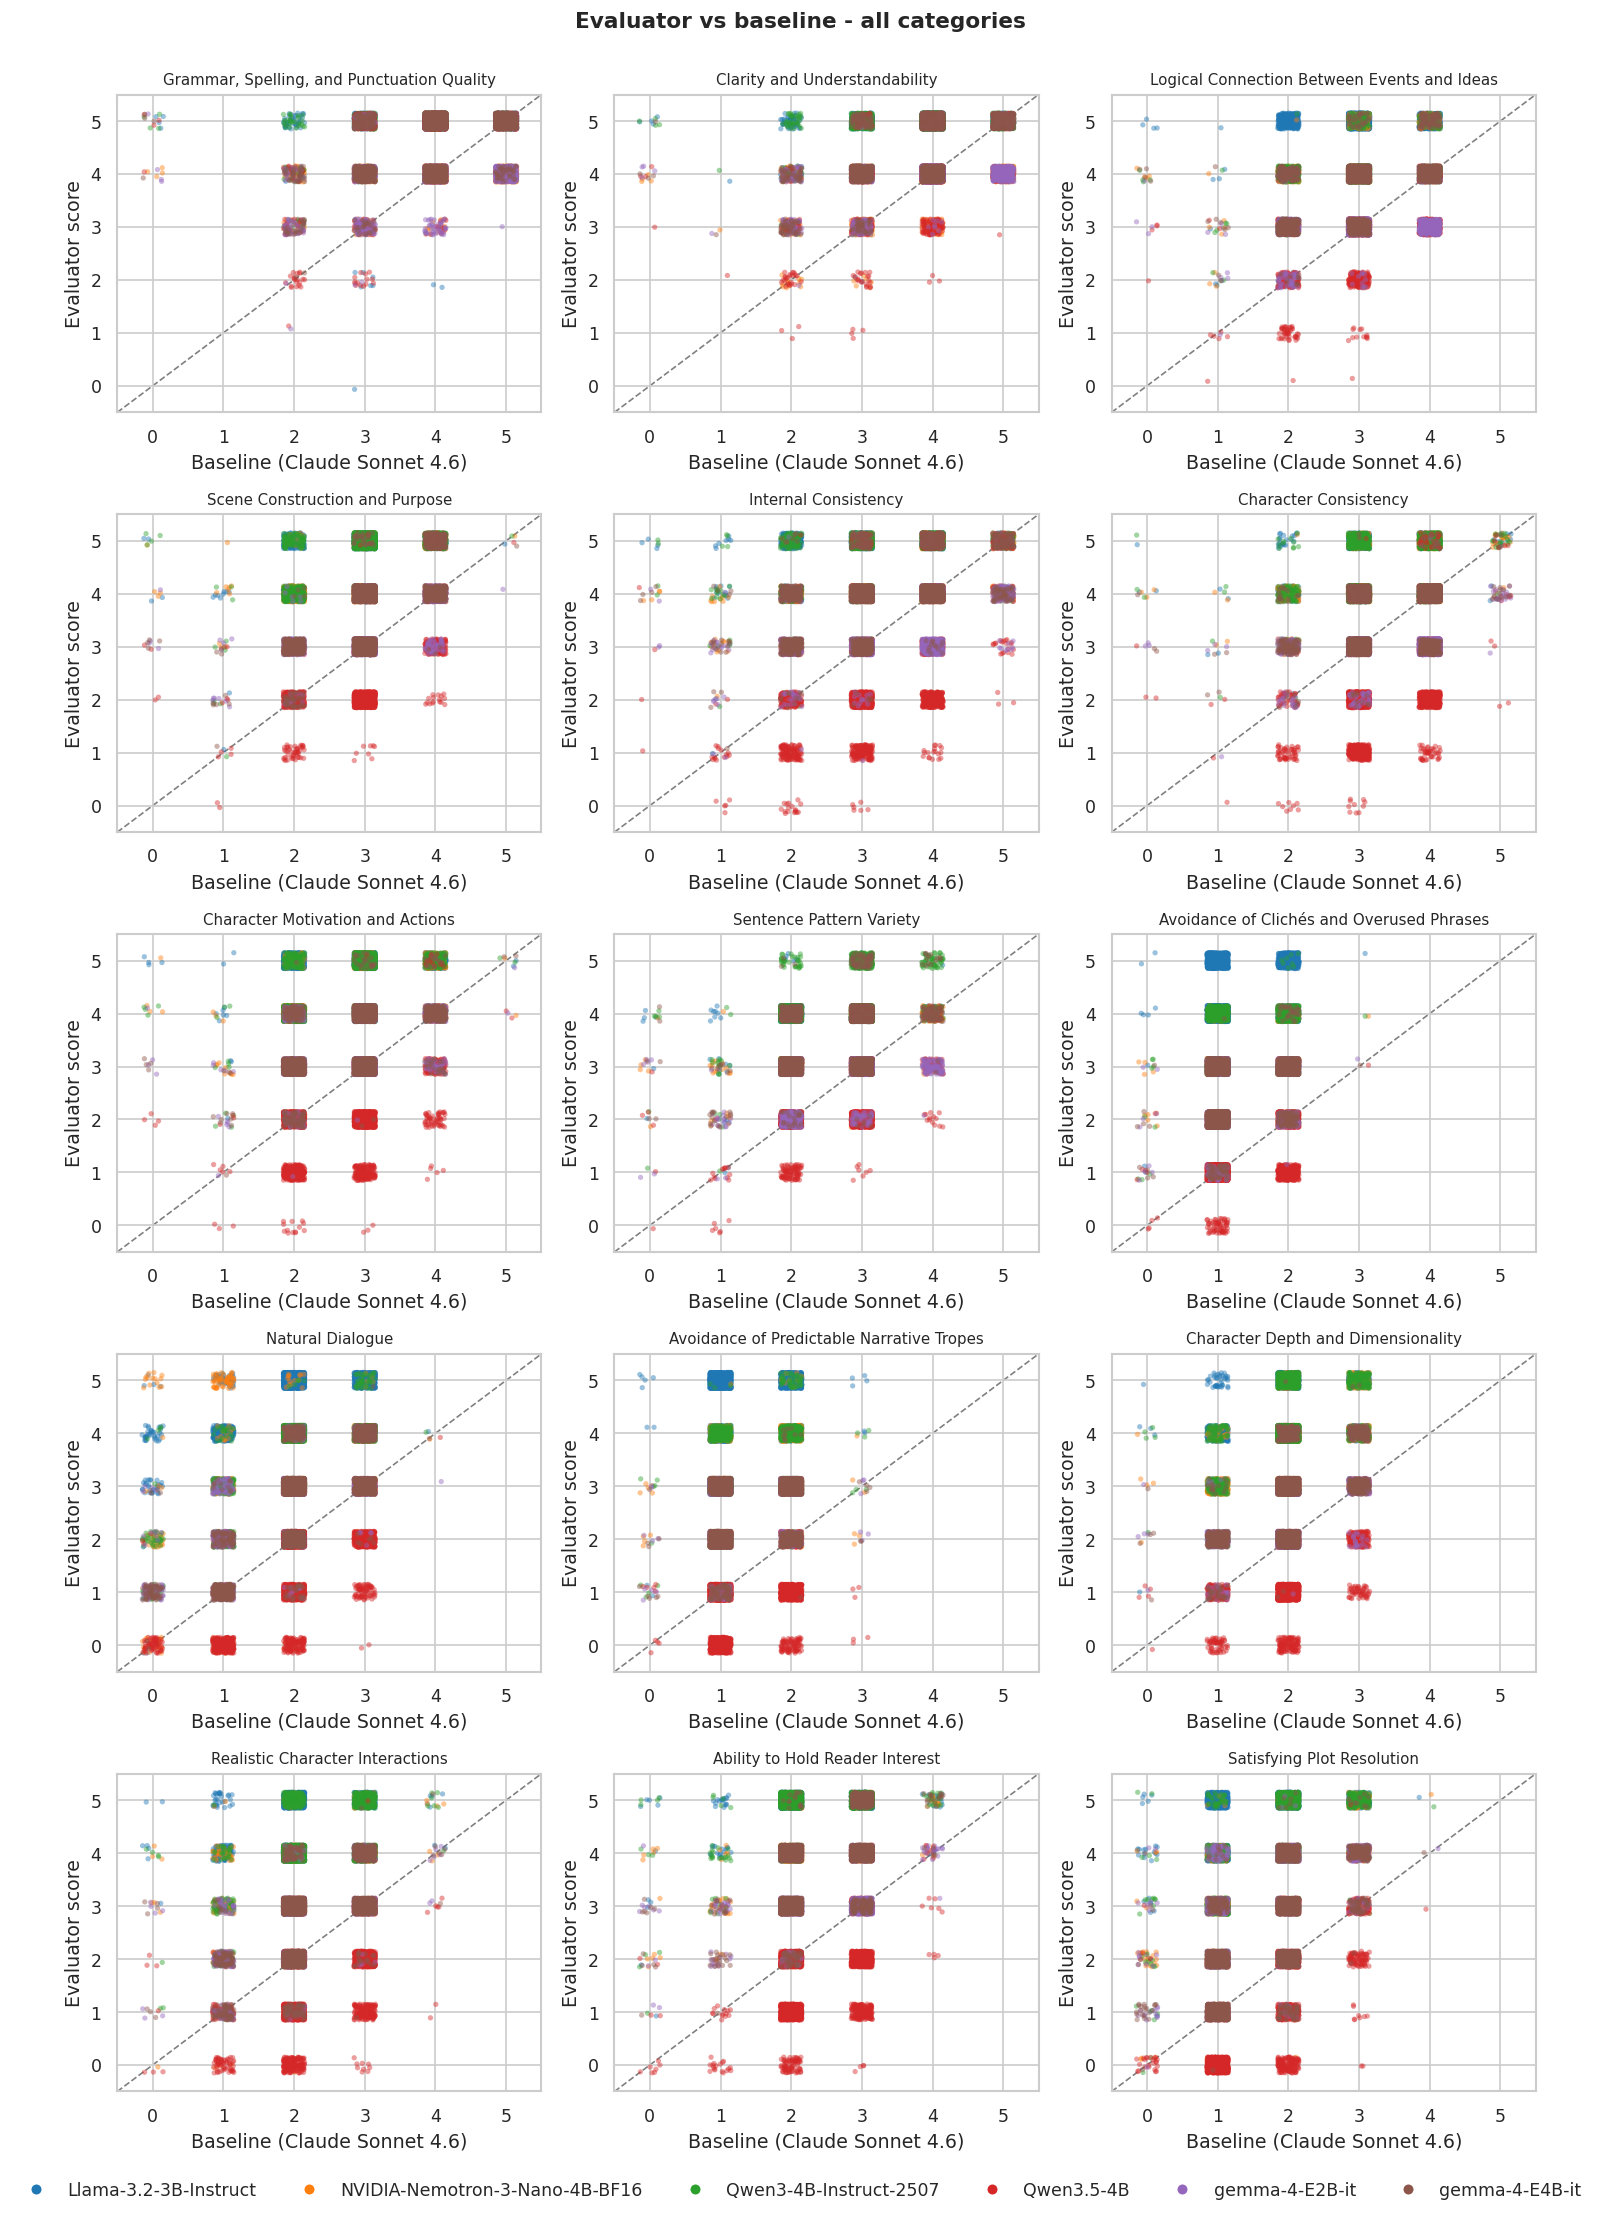

In [13]:
scatter_grid(ALL_CATEGORIES, "Evaluator vs baseline - all categories")

## Agreement heatmaps & bootstrap stability

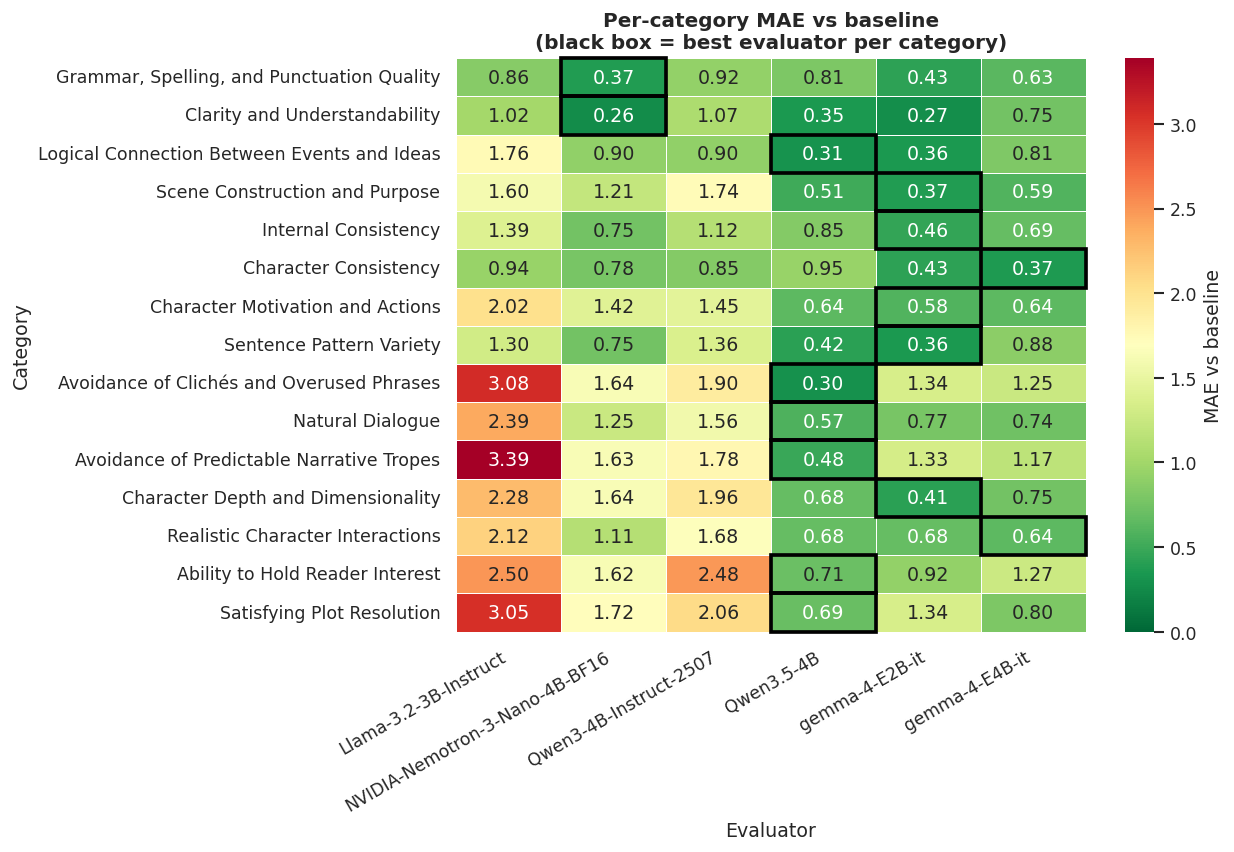

,evaluator,category,type,n,mae,bias
0,Llama-3.2-3B-Instruct,Ability to Hold Reader Interest,positive,3480,2.500287,2.500287
1,NVIDIA-Nemotron-3-Nano-4B-BF16,Ability to Hold Reader Interest,positive,3480,1.617529,1.616954
2,Qwen3-4B-Instruct-2507,Ability to Hold Reader Interest,positive,3480,2.478448,2.478448
3,Qwen3.5-4B,Ability to Hold Reader Interest,positive,3480,0.709483,-0.646839
4,gemma-4-E2B-it,Ability to Hold Reader Interest,positive,3480,0.916379,0.915805
...,...,...,...,...,...,...
85,NVIDIA-Nemotron-3-Nano-4B-BF16,Sentence Pattern Variety,positive,3480,0.748851,0.743103
86,Qwen3-4B-Instruct-2507,Sentence Pattern Variety,positive,3480,1.364655,1.364655
87,Qwen3.5-4B,Sentence Pattern Variety,positive,3480,0.423563,-0.231034
88,gemma-4-E2B-it,Sentence Pattern Variety,positive,3480,0.355172,0.274138


In [14]:
def compute_agreement(pairs_df):
    rows = []
    for (ev, cat), g in pairs_df.groupby(["evaluator", "category"]):
        x = g["baseline"].to_numpy()
        y = g["score"].to_numpy()
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]
        diff = y - x
        rows.append({
            "evaluator": ev,
            "category":  cat,
            "type":      g["type"].iloc[0],
            "n":         int(len(x)),
            "mae":       float(np.abs(diff).mean()) if len(diff) else np.nan,
            "bias":      float(diff.mean()) if len(diff) else np.nan,
        })
    return pd.DataFrame(rows)


def plot_agreement_heatmap(pairs_df, title="Per-category MAE vs baseline",
                           highlight_winner=True):
    agree_df = compute_agreement(pairs_df)
    pivot = (
        agree_df.pivot_table(index="category", columns="evaluator", values="mae")
                .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
    )
    plt.figure(figsize=(1.1 * len(evaluator_names) + 4, 0.35 * len(pivot) + 2))
    ax = sns.heatmap(pivot, cmap="RdYlGn_r", vmin=0,
                     annot=True, fmt=".2f", linewidths=0.4, linecolor="white",
                     cbar_kws={"label": "MAE vs baseline"})
    if highlight_winner:
        min_cols = pivot.idxmin(axis=1)
        for row_idx, cat in enumerate(pivot.index):
            ev = min_cols.loc[cat]
            if pd.isna(ev): continue
            col_idx = pivot.columns.get_loc(ev)
            ax.add_patch(mpatches.Rectangle((col_idx, row_idx), 1, 1,
                                            fill=False, edgecolor="black", lw=2.2, clip_on=False))
        title = f"{title}\n(black box = best evaluator per category)"
    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Evaluator")
    plt.ylabel("Category")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    return ax


agreement = compute_agreement(pairs)
plot_agreement_heatmap(pairs)
plt.show()
display(agreement.sort_values(["category", "evaluator"]).reset_index(drop=True))

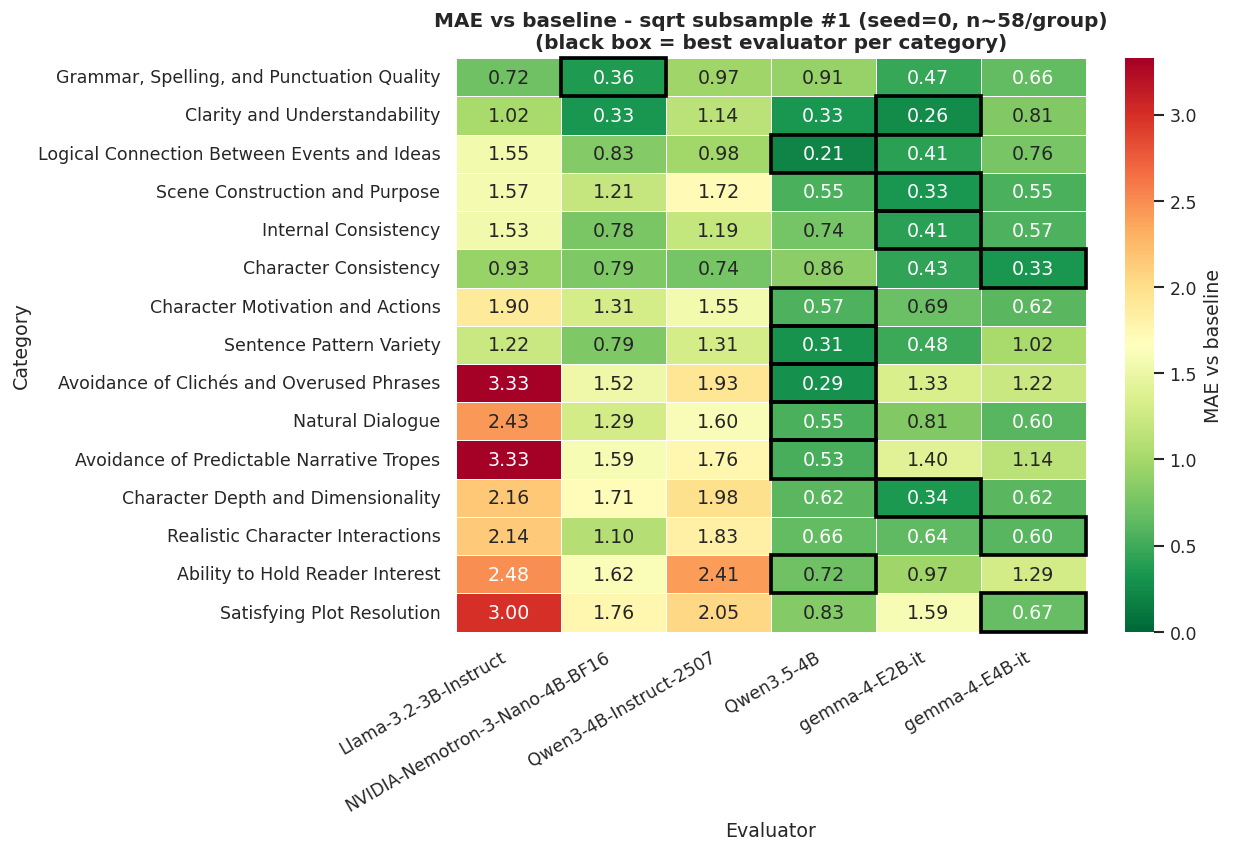

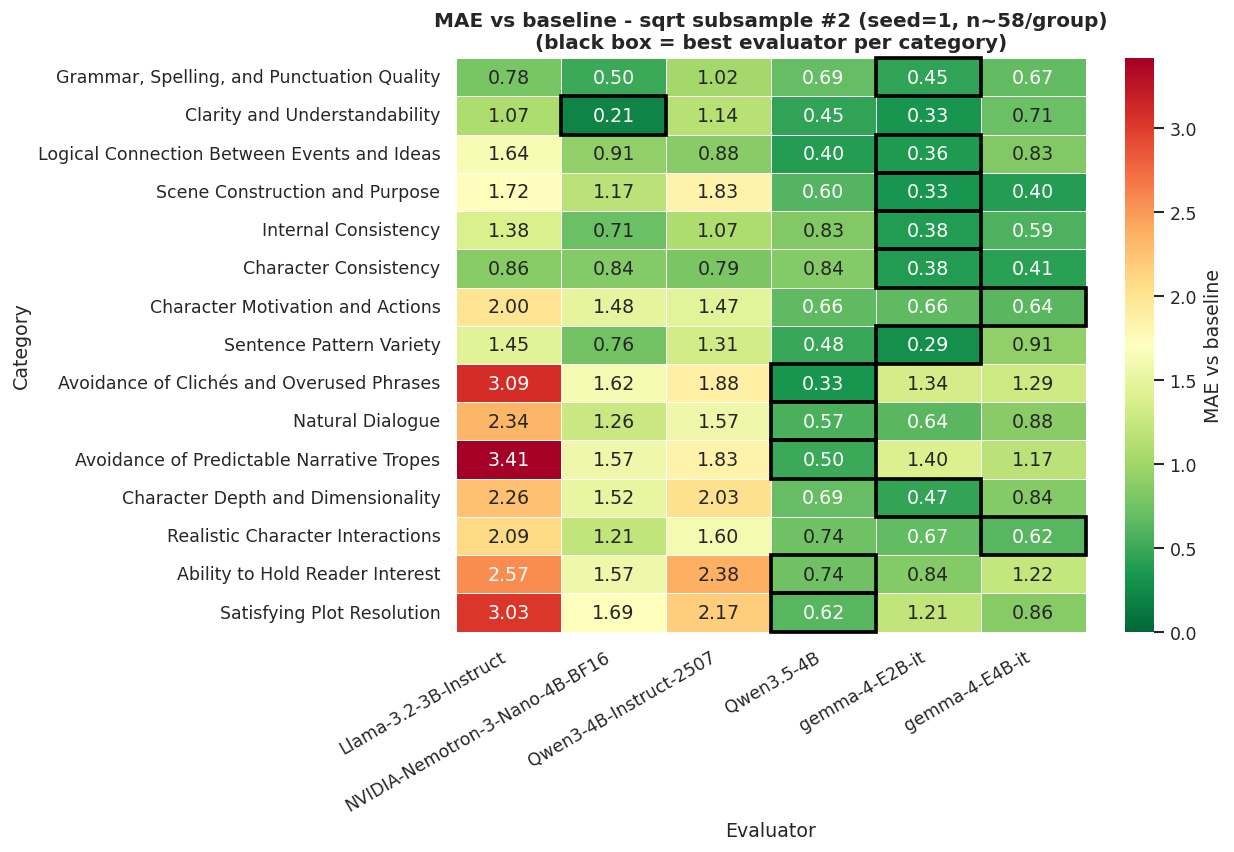

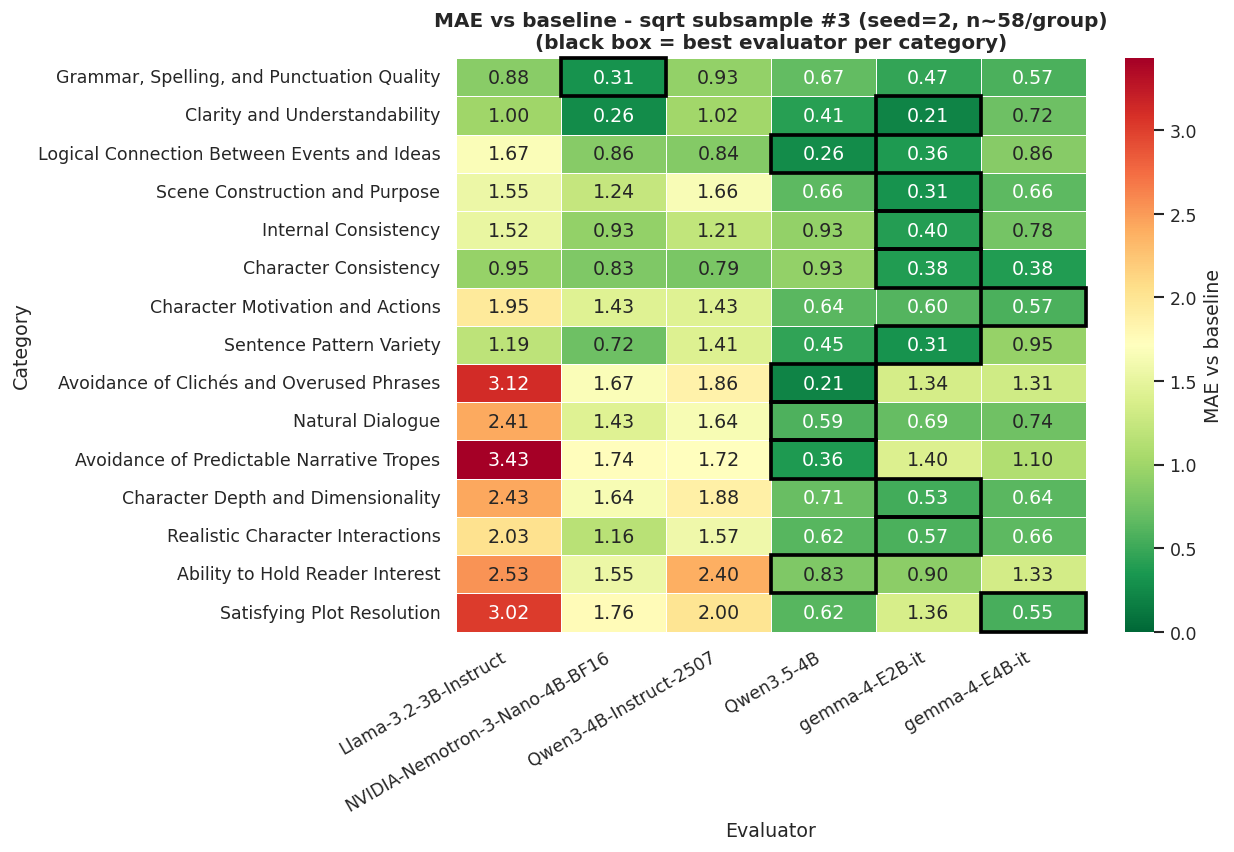

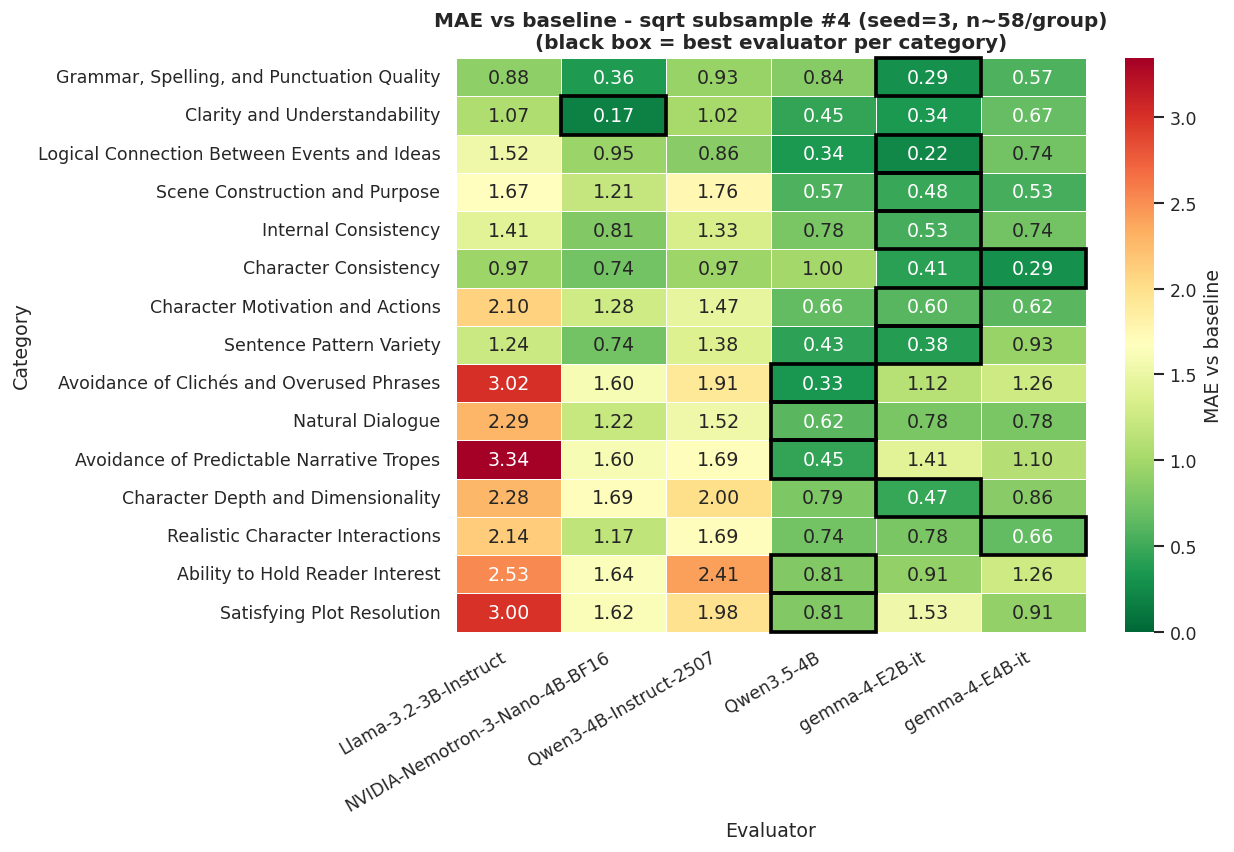

In [15]:
def sqrt_subsample(pairs_df, seed):
    rng = np.random.default_rng(seed)
    parts = []
    for _, g in pairs_df.groupby(["evaluator", "category"], sort=False):
        k = max(2, int(np.sqrt(len(g))))
        idx = rng.choice(len(g), size=min(k, len(g)), replace=False)
        parts.append(g.iloc[idx])
    return pd.concat(parts, ignore_index=True)


N_FIGURES = 4
for i in range(N_FIGURES):
    sample = sqrt_subsample(pairs, seed=i)
    n_per_group = int(np.sqrt(len(pairs) // (len(evaluator_names) * len(ALL_CATEGORIES))))
    plot_agreement_heatmap(
        sample,
        title=(f"MAE vs baseline - sqrt subsample #{i + 1} "
               f"(seed={i}, n~{n_per_group}/group)"),
    )
    plt.tight_layout()
    plt.show()

## LaTeX tabular

In [17]:
def to_latex_tabular(pivot_df):
    """LaTeX tabular string; bold = lowest MAE (best) per row."""
    cols = list(pivot_df.columns)
    lines = []
    lines.append(r"\begin{tabular}{l" + "r" * len(cols) + "}")
    lines.append(r"\toprule")
    lines.append("Rubric & " + " & ".join(cols) + r" \\")
    lines.append(r"\midrule")
    for cat, row in pivot_df.iterrows():
        best = row.idxmin()
        cells = []
        for ev in cols:
            v = row[ev]
            s = f"{v:.3f}" if not pd.isna(v) else "--"
            cells.append(r"\textbf{" + s + "}" if ev == best else s)
        lines.append(f"{cat} & " + " & ".join(cells) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


mae_pivot = (
    agreement.pivot_table(index="category", columns="evaluator", values="mae")
             .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)
print(to_latex_tabular(mae_pivot))

\begin{tabular}{lrrrrrr}
\toprule
Rubric & Llama-3.2-3B-Instruct & NVIDIA-Nemotron-3-Nano-4B-BF16 & Qwen3-4B-Instruct-2507 & Qwen3.5-4B & gemma-4-E2B-it & gemma-4-E4B-it \\
\midrule
Grammar, Spelling, and Punctuation Quality & 0.857 & \textbf{0.372} & 0.922 & 0.805 & 0.431 & 0.625 \\
Clarity and Understandability & 1.016 & \textbf{0.261} & 1.066 & 0.353 & 0.268 & 0.745 \\
Logical Connection Between Events and Ideas & 1.758 & 0.902 & 0.902 & \textbf{0.305} & 0.357 & 0.810 \\
Scene Construction and Purpose & 1.599 & 1.206 & 1.743 & 0.509 & \textbf{0.371} & 0.591 \\
Internal Consistency & 1.390 & 0.750 & 1.115 & 0.846 & \textbf{0.457} & 0.686 \\
Character Consistency & 0.943 & 0.775 & 0.846 & 0.953 & 0.429 & \textbf{0.370} \\
Character Motivation and Actions & 2.016 & 1.424 & 1.448 & 0.641 & \textbf{0.584} & 0.639 \\
Sentence Pattern Variety & 1.298 & 0.749 & 1.365 & 0.424 & \textbf{0.355} & 0.879 \\
Avoidance of Clichés and Overused Phrases & 3.082 & 1.639 & 1.895 & \textbf{0.303} & 1.34